# Polarization of light is a qubit

### Subject: Optics

A linear polarization state maps exactly onto the computational basis of a
qubit: $|H\rangle \leftrightarrow |0\rangle$, $|V\rangle \leftrightarrow |1\rangle$.
Malus's law for polarizers becomes the Born measurement rule.


## 0. Setup


In [1]:
import sys
from pathlib import Path

# Make quantum/_common importable whether the kernel cwd is the repo root
# or the subject folder.
_here = Path.cwd().resolve()
for candidate in (_here, _here.parent, _here.parent.parent):
    if (candidate / "_common").is_dir():
        sys.path.insert(0, str(candidate))
        break

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

from _common import ket0, ket1

def polarization_state(theta_deg: float) -> np.ndarray:
    """Linear polarization at angle theta w.r.t. horizontal."""
    theta = np.deg2rad(theta_deg)
    return np.cos(theta) * ket0 + np.sin(theta) * ket1


def malus_from_born(theta_deg: float) -> float:
    """P(pass horizontal polarizer) = |<H|psi>|^2 = cos^2(theta)."""
    psi = polarization_state(theta_deg)
    amp_H = (ket0.conj().T @ psi).item()
    return float(abs(amp_H) ** 2)

print("Helpers ready.")


Helpers ready.


## 1. Malus = Born

A photon polarized at angle $\theta$ hitting a horizontal polarizer is measured
in the $\{|H\rangle, |V\rangle\}$ basis. The Born rule gives

$$ P(\text{pass}) = |\langle H|\psi(\theta)\rangle|^2 = \cos^2\theta, $$

which is exactly **Malus's law**.


In [2]:
print("theta [deg] | P(pass) | cos^2(theta)")
print("-" * 40)
for theta in (0, 30, 45, 60, 90):
    p = malus_from_born(theta)
    print(f"{theta:>10} | {p:7.3f} | {np.cos(np.deg2rad(theta))**2:7.3f}")


theta [deg] | P(pass) | cos^2(theta)
----------------------------------------
         0 |   1.000 |   1.000
        30 |   0.750 |   0.750
        45 |   0.500 |   0.500
        60 |   0.250 |   0.250
        90 |   0.000 |   0.000


## 2. Plot the transmission curve


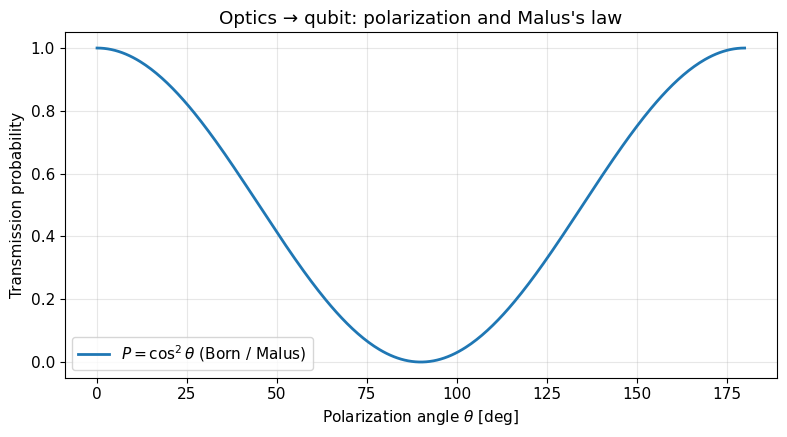

In [3]:
thetas = np.linspace(0, 180, 361)
probs = [malus_from_born(t) for t in thetas]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thetas, probs, lw=2, label=r"$P=\cos^2\theta$ (Born / Malus)")
ax.set_xlabel(r"Polarization angle $\theta$ [deg]")
ax.set_ylabel("Transmission probability")
ax.set_title("Optics → qubit: polarization and Malus's law")
ax.legend()
plt.tight_layout()
plt.show()


### Next steps
- Model a 50/50 beam splitter as a Hadamard gate.
- Mach–Zehnder interferometer and single-photon interference.
- Waveplates as rotations on the Bloch sphere.
